# 모바일 GPS 로그 (mGps) 심층 EDA

이 노트북은 모바일 GPS 데이터 파일인 `ch2025_mGps.parquet`을 깊이 있게 탐색합니다.
GPS 데이터를 통해 이동성(Mobility)과 외출 패턴, 생활 반경 등을 계산할 수 있습니다.

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 테마 설정 시 폰트 정보를 함께 주입하여 덮어쓰기 방지 (Windows/Mac/Linux 대응)
sns.set_theme(
    style="whitegrid",
    rc={
        "font.family": "sans-serif",
        "font.sans-serif": [
            "Malgun Gothic",
            "AppleGothic",
            "NanumGothic",
            "DejaVu Sans",
            "Arial",
            "Helvetica",
            "sans-serif",
        ],
        "axes.unicode_minus": False,
    },
)
plt.rcParams["figure.figsize"] = (12, 6)

# 현재 스크립트/노트북 위치 기준의 절대 경로 기준점 정의 (어디서 실행해도 경로 에러 방지)
BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if "__file__" in locals() else os.getcwd()

DATA_PATH = os.path.join(BASE_DIR, "../../data/ch2025_data_items/ch2025_mGps.parquet")
df = pd.read_parquet(DATA_PATH)

## 1. 데이터 확인

In [7]:
print(f"데이터 크기 (Shape): {df.shape}")
df.head()

데이터 크기 (Shape): (800611, 3)


,subject_id,timestamp,m_gps
0,id01,2024-06-26 12:03:00,"[{'altitude': 110.6, 'latitude': 0.2077385, 'l..."
1,id01,2024-06-26 12:04:00,"[{'altitude': 110.8, 'latitude': 0.2078068, 'l..."
2,id01,2024-06-26 12:05:00,"[{'altitude': 110.7, 'latitude': 0.2078214, 'l..."
3,id01,2024-06-26 12:06:00,"[{'altitude': 110.7, 'latitude': 0.2078395, 'l..."
4,id01,2024-06-26 12:07:00,"[{'altitude': 110.8, 'latitude': 0.2078478, 'l..."


## 1.5. GPS 로그 평준화 (Flattening) 및 데이터 확인

`m_gps` 컬럼은 각 시점별 GPS 기록 리스트로 구성되어 있습니다.
전체 데이터(약 850만 개의 GPS 포인트)를 한 번에 평준화하는 것은 메모리와 시간에 부담을 주므로,
상위 일부 행에 대해 평준화(explode)를 진행하여 상세 데이터 구조를 확인합니다.

### 📌 평준화된 GPS 데이터 컬럼 의미:
- **`altitude`**: 수집기기 기준의 고도 값 (미터(m) 단위).
- **`latitude`**: 위도 값 (※ 본 대회에서는 참여자의 실제 위치 비식별화를 위해 **상대좌표**로 변환되어 제공됩니다).
- **`longitude`**: 경도 값 (※ 본 대회에서는 참여자의 실제 위치 비식별화를 위해 **상대좌표**로 변환되어 제공됩니다).
- **`speed`**: 이동 속도 값 (※ 데이터 수집 환경에 따라 m/s와 km/h 단위가 혼재되어 기록되었을 수 있으므로 전처리 및 피처 생성 시 주의가 필요합니다).

In [8]:
# 상위 20개 행을 대상으로 평준화 진행 (90개 이상의 행 확보)
df_gps_flat = df.head(20).explode("m_gps").reset_index(drop=True)
df_gps_flat = df_gps_flat[df_gps_flat["m_gps"].notna()]

# 딕셔너리 리스트 해제
gps_normalized = pd.json_normalize(df_gps_flat["m_gps"])
df_gps_flat = pd.concat([df_gps_flat.drop(columns=["m_gps"]), gps_normalized], axis=1)

print(f"평준화된 GPS 데이터 크기 (Shape): {df_gps_flat.shape}")
df_gps_flat.head(90)

평준화된 GPS 데이터 크기 (Shape): (222, 6)


,subject_id,timestamp,altitude,latitude,longitude,speed
0,id01,2024-06-26 12:03:00,110.6,0.207738,0.170027,0.0000
1,id01,2024-06-26 12:03:00,110.8,0.207776,0.169985,0.7210
2,id01,2024-06-26 12:03:00,110.8,0.207773,0.169983,0.0505
3,id01,2024-06-26 12:03:00,110.7,0.207790,0.169969,0.6587
4,id01,2024-06-26 12:03:00,110.7,0.207791,0.169971,0.0568
...,...,...,...,...,...,...
85,id01,2024-06-26 12:10:00,110.8,0.207855,0.169962,0.0194
86,id01,2024-06-26 12:10:00,110.6,0.207855,0.169962,0.0027
87,id01,2024-06-26 12:10:00,110.6,0.207855,0.169962,0.0047
88,id01,2024-06-26 12:10:00,110.6,0.207854,0.169961,0.0086


## 2. 수집된 GPS 데이터 포인트 개수 분석
각 스캔 위치당 기록된 위치 좌표의 개수 분포를 파악합니다.

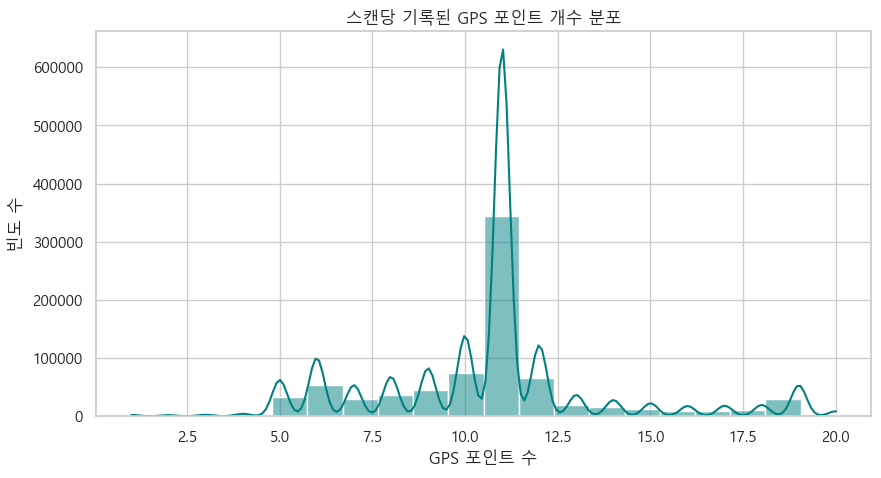

In [9]:
df["gps_log_count"] = df["m_gps"].apply(lambda x: len(x) if x is not None else 0)

plt.figure(figsize=(10, 5))
sns.histplot(df["gps_log_count"], bins=20, color="teal", kde=True)
plt.title("스캔당 기록된 GPS 포인트 개수 분포")
plt.xlabel("GPS 포인트 수")
plt.ylabel("빈도 수")
plt.savefig(os.path.join(BASE_DIR, "reports/images/05_gps_log_count_distribution.png"), bbox_inches="tight", dpi=150)
plt.show()

In [ ]:
df["gps_log_count"].describe()

### 2.1. 참여자별 GPS 데이터 포인트 개수 비교
참여자별로 한 스캔 주기당 기록되는 GPS 데이터 포인트 수의 분포를 비교합니다.

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="subject_id", y="gps_log_count", hue="subject_id", palette="Set3", legend=False)
plt.title("참여자별 한 스캔당 GPS 포인트 수 분포 비교")
plt.xlabel("참여자 ID")
plt.ylabel("GPS 포인트 수")
plt.savefig(os.path.join(BASE_DIR, "reports/images/05_subject_device_count_boxplot.png"), bbox_inches="tight", dpi=150)
plt.show()

### 2.2. 참여자별 시간대별 GPS 데이터 수집 흐름
각 참여자가 하루 중 어느 시간대에 GPS 수집 빈도가 높아지는지 확인합니다.

In [ ]:
df["hour"] = df["timestamp"].dt.hour
hourly_gps = df.groupby(["subject_id", "hour"])["gps_log_count"].mean().reset_index()

subjects = sorted(df["subject_id"].unique())
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()

for idx, sub in enumerate(subjects):
    sub_data = hourly_gps[hourly_gps["subject_id"] == sub]
    axes[idx].plot(sub_data["hour"], sub_data["gps_log_count"], color="teal", linewidth=2, marker="o")
    axes[idx].set_title(f"참여자: {sub}", fontsize=11, fontweight="bold")
    axes[idx].set_xticks(range(0, 24, 4))

plt.suptitle("참여자별 시간대별 평균 수집 GPS 포인트 수 흐름", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "reports/images/05_subject_hourly_device_count_flow.png"), bbox_inches="tight", dpi=150)
plt.show()

## 3. 속도(Speed) 분포 탐색
GPS 데이터에서 측정된 이동 속도 정보를 확인하여 정지 상태와 이동 상태를 구분해 봅니다.

추출된 속도 데이터 수: 32120


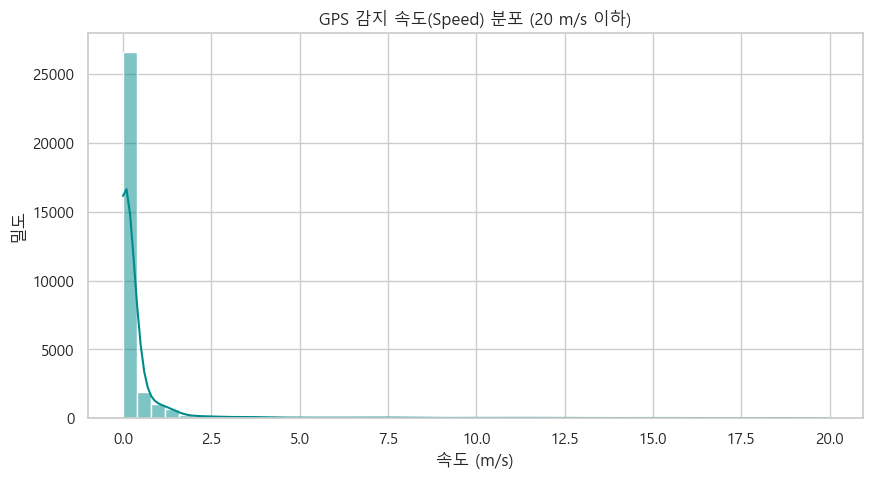

In [10]:
# 샘플로 몇 개의 행에서 속도 정보를 파싱하여 분포를 봅니다.
speeds = []
for path in df["m_gps"].sample(3000, random_state=42):
    for point in path:
        if "speed" in point:
            speeds.append(point["speed"])

speeds = np.array(speeds)
print(f"추출된 속도 데이터 수: {len(speeds)}")

plt.figure(figsize=(10, 5))
sns.histplot(speeds[speeds < 20], bins=50, kde=True, color="darkcyan")  # 이상치 제외 속도만 시각화
plt.title("GPS 감지 속도(Speed) 분포 (20 m/s 이하)")
plt.xlabel("속도 (m/s)")
plt.ylabel("밀도")
plt.savefig(os.path.join(BASE_DIR, "reports/images/05_gps_speed_distribution.png"), bbox_inches="tight", dpi=150)
plt.show()

### 3.1. 참여자별 최대 이동 속도 분포 비교
각 수집 로그별 최대 속도를 계산하여 참여자들의 이동 속도 분포를 비교합니다.

C:\Users\pilla\AppData\Local\Temp\ipykernel_42088\2611391241.py:17: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:teal'` for the same effect.

  sns.barplot(data=moving_pattern, x="hour", y="is_moving", hue="hour", color="teal", legend=False)


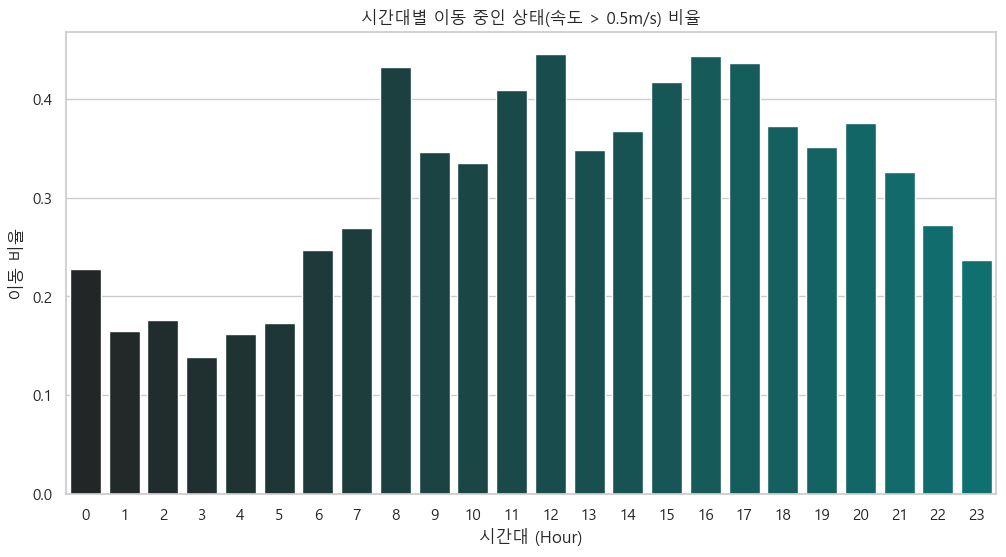

In [11]:
# 각 로그별 최대 속도 추출 (전체 데이터 대상)
def get_max_speed(gps_array):
    if gps_array is None or len(gps_array) == 0:
        return 0.0
    return max([p.get("speed", 0.0) for p in gps_array])

df["max_speed"] = df["m_gps"].apply(get_max_speed)

plt.figure(figsize=(12, 6))
# 시각화 편의를 위해 극단적인 이상치(차량 속도 이상 등)를 제외하고 30 m/s 이하인 범위만 박스플롯으로 시각화합니다.
sns.boxplot(data=df[df["max_speed"] < 30], x="subject_id", y="max_speed", hue="subject_id", palette="Set3", legend=False)
plt.title("참여자별 감지되는 최대 이동 속도 분포 비교 (30 m/s 이하)")
plt.xlabel("참여자 ID")
plt.ylabel("최대 이동 속도 (m/s)")
plt.savefig(os.path.join(BASE_DIR, "reports/images/05_subject_max_speed_boxplot.png"), bbox_inches="tight", dpi=150)
plt.show()

## 4. 시간대별 이동 패턴 분석 (이동 속도가 0.5 m/s 이상인 빈도)
속도가 0.5 m/s(약 1.8 km/h) 이상인 경우 이동 상태로 판별하고, 시간대별 이동 상태의 비율을 전체 및 참여자별로 비교합니다.

In [ ]:
df["is_moving"] = (df["max_speed"] > 0.5).astype(int)

# 전체 시간대별 이동 비율
moving_pattern = df.groupby("hour")["is_moving"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=moving_pattern, x="hour", y="is_moving", hue="hour", color="teal", legend=False)
plt.title("전체 시간대별 이동 중인 상태(속도 > 0.5m/s) 비율")
plt.xlabel("시간대 (Hour)")
plt.ylabel("이동 비율")
plt.savefig(os.path.join(BASE_DIR, "reports/images/05_moving_ratio_distribution.png"), bbox_inches="tight", dpi=150)
plt.show()

### 4.1. 참여자별 시간대별 이동 상태 비율 흐름
참여자 개개인의 하루 중 이동 경향성과 패턴 차이를 심층적으로 파악합니다.

In [ ]:
hourly_moving = df.groupby(["subject_id", "hour"])["is_moving"].mean().reset_index()

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()

for idx, sub in enumerate(subjects):
    sub_data = hourly_moving[hourly_moving["subject_id"] == sub]
    axes[idx].plot(sub_data["hour"], sub_data["is_moving"], color="darkcyan", linewidth=2, marker="o")
    axes[idx].set_title(f"참여자: {sub}", fontsize=11, fontweight="bold")
    axes[idx].set_xticks(range(0, 24, 4))

plt.suptitle("참여자별 시간대별 이동 중인 상태(속도 > 0.5m/s) 비율 흐름", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "reports/images/05_subject_hourly_moving_flow.png"), bbox_inches="tight", dpi=150)
plt.show()

## 5. 피처 엔지니어링 제안
* **`gps_total_records`**: 하루 동안 수집된 총 GPS 로그 개수 (기기 활성화 정도).
* **`gps_max_speed`**: 하루 중 감지된 최대 속도 (차량 탑승 여부 판단 피처).
* **`gps_location_entropy`**: 위경도 그리드화를 통한 위치 엔드로피 (주 생활 반경의 다양성).